In [1]:
import xarray as xr
import earthaccess
import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import rasterio
import datetime
import pyarrow as pa
import pyarrow.parquet as pq
import os
import numpy as np

warnings.filterwarnings('ignore')
%matplotlib inline

In [9]:
fires = pd.read_parquet("s3://maap-ops-workspace/shared/zbecker/TESS_fire_spread/sigdeltas_Tess.parq")
subset_fires = gpd.read_parquet("s3://maap-ops-workspace/shared/zbecker/YANG/large_feds_faf_double_matched.parq")
subset_fires = subset_fires.to_crs(4326)

subset_fires["centroid"] = subset_fires.to_crs(4326).centroid
fires["UfireID"] = fires.mergeid.astype("int").astype("str") + "_" + fires.year.astype("str")
subset_fires["UfireID"] = subset_fires.mergeid.astype("str") + "_" + subset_fires.year.astype("str")
subset_fires["polygon"] = subset_fires.geometry
fires = fires[fires.UfireID.isin(subset_fires[subset_fires.intersectsMTBS == True].UfireID)]
fname = pd.read_csv("s3://maap-ops-workspace/shared/zbecker/Eli_MTBS_vs_FEDS/v6_output.csv")

fires = fires.merge(subset_fires[['UfireID', 'centroid', 'polygon']], on = 'UfireID' )
fires = gpd.GeoDataFrame(fires, geometry = 'polygon')

def get_st_sp_fire(df, days_after = 7):
    df.loc[:, "start_time"] = df.t.min()
    df.loc[:, "end_time"] = df.t.max()
    df.loc[:, "end_time_plus"] = df.t.astype("datetime64[ns]").max()  + datetime.timedelta(days = days_after)
    df = df.loc[df.t == df.t.max(), :]
    return(df)
    
fires_sm = fires.groupby("UfireID").apply(get_st_sp_fire).reset_index(drop = True)
fires_sm["stable_index"] = fires_sm.index

In [10]:
precip = pd.read_parquet(os.path.abspath("IMERG/half_hourly_IMERG_precip"))

In [11]:
precip = precip.merge(fires_sm[["UfireID",	"centroid"]], on = "UfireID")

precip.loc[:, "lon"] = precip.centroid.apply(lambda p: p.x)

In [12]:
precip.loc[:, "offset_hour"] = (precip.lon/15)

precip.loc[:, "time_lst"] = precip.time_utc.astype("datetime64[ns]") + pd.to_timedelta(precip["offset_hour"], unit='h') #lst_to_utc_offset_hours =  lon/ 15.0

pm_mask = (precip.time_lst.dt.hour > 6) & (precip.time_lst.dt.hour <= 18) ## correcting to PM 13:30 overpass
am_mask = (precip.time_lst.dt.hour <= 6) | ((precip.time_lst.dt.hour >= 18))## correcting to AM 1:30 overpass. This is actually an exact  number not a range bc we calcuated it for the extraction. 

precip.loc[pm_mask, "t"] = precip.loc[pm_mask, "time_lst"].dt.normalize() + pd.Timedelta(hours=12)
precip.loc[am_mask, "t"] = precip.loc[am_mask, "time_lst"].dt.normalize() + pd.Timedelta(hours=0)





In [13]:
## Finding days_since_t
fires.t = fires.t.astype('datetime64[ns]')
fires = fires.merge(precip[[ 'precipitation', 'UfireID', 't']], how = 'outer', on = ['UfireID', 't'])

fires = fires.merge(fires_sm[['UfireID', 'start_time', 'end_time','end_time_plus']], on = 'UfireID')

# foo = fires[fires.UfireID == "10000_2019"]
# foo = foo.sort_values(by = "t")
# foo




## Extraction included the precip values from BEFORE the fire's first growth increment

In [29]:
## Calculating time offset from ending
fires['end_time_offset'] =  fires.t.astype("datetime64[ns]") - fires.end_time.astype("datetime64[ns]") # Positive means days past the end date
fires['start_time_offset'] = fires.t.astype("datetime64[ns]") - fires.start_time.astype("datetime64[ns]") # Positive means days past the start date, negative means before
fires['start_off_12hrs'] = fires['start_time_offset'] / pd.Timedelta(hours=12) 
fires['end_off_12hrs'] = fires['end_time_offset'] / pd.Timedelta(hours=12)

### calculating timeoffset from begining

# Plots!

Text(0.5, 0.98, '4190 fires, from 2012 to 2022')

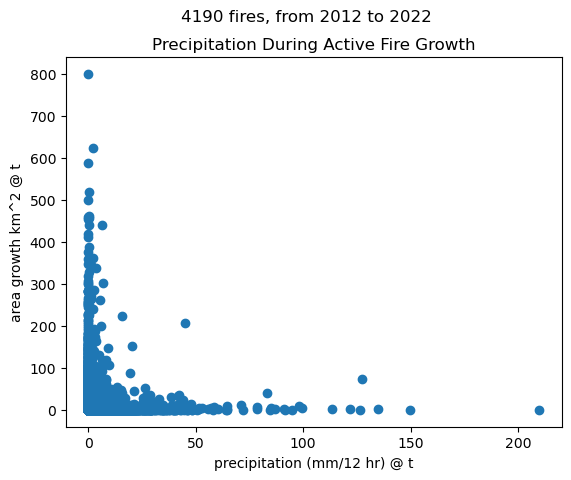

In [49]:

af_mask =  (fires['start_off_12hrs'] >= 0) & (fires['end_off_12hrs'] <= 0)

plt.scatter(y = fires[af_mask].area_growth_at_t_km2, x = fires[af_mask].precipitation)
plt.xlabel("precipitation (mm/12 hr) @ t")
plt.ylabel("area growth km^2 @ t")
plt.title("Precipitation During Active Fire Growth")
plt.suptitle(f"{fires[af_mask].UfireID.nunique()} fires, from {fires[af_mask].t.dt.year.min()} to {fires[af_mask].t.dt.year.max()}")

# Zeb's dataset doesn't have the non-spread timesteps, so we don't have the times when firegrowth = 0 in the above plot

In [50]:
fires.loc[af_mask & (fires.area_growth_at_t_km2.isna()), "area_growth_at_t_km2"] = 0

Text(0.5, 0.98, '4190 fires, from 2012 to 2022')

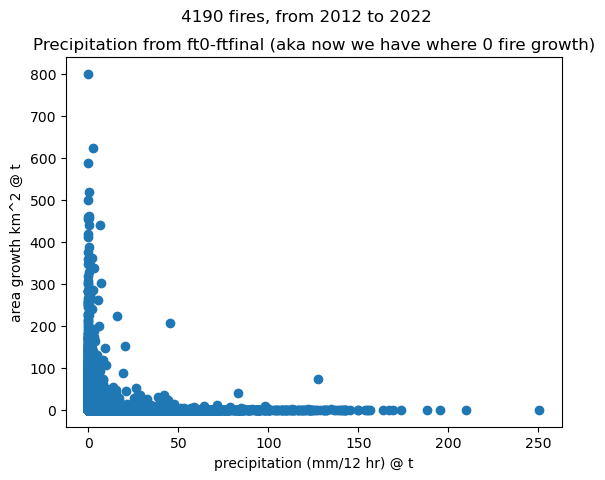

In [52]:
plt.scatter(y = fires[af_mask].area_growth_at_t_km2, x = fires[af_mask].precipitation)
plt.xlabel("precipitation (mm/12 hr) @ t")
plt.ylabel("area growth km^2 @ t")
plt.title("Precipitation from ft0-ftfinal (aka now we have where 0 fire growth)")
plt.suptitle(f"{fires[af_mask].UfireID.nunique()} fires, from {fires[af_mask].t.dt.year.min()} to {fires[af_mask].t.dt.year.max()}")

#### How many fires ended after precipitation? 

I will look at the distribution of precip 
 - after fires ended (12 hour increment to start out)
 - during fires
 - before fires started (12 hour increment)
 - if ending precip bigger than during precip important? (dunno)





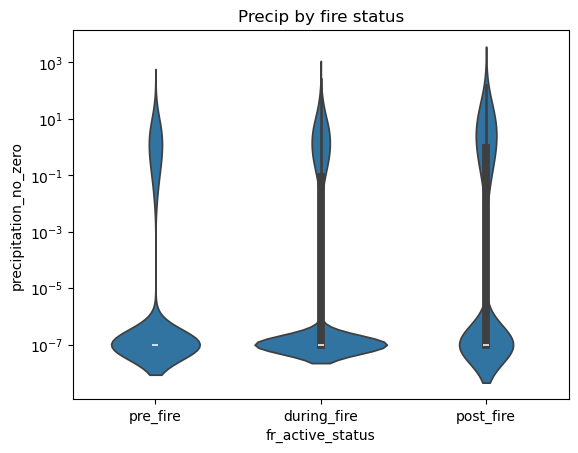

In [70]:
import seaborn as sns

### set up column for easly plotting 

pre_fire_mask = fires.start_off_12hrs == -1 ## conservative, next 12 hours, could expand to 24 because of differences in detection effecientcy
post_fire_mask = fires.end_off_12hrs == 1


fires.loc[pre_fire_mask, "fr_active_status"] = "pre_fire"
fires.loc[post_fire_mask, "fr_active_status"] = "post_fire"
fires.loc[af_mask, "fr_active_status"] = "during_fire"
fires.loc[:, "precipitation_no_zero"] = fires["precipitation"] + 0.0000001

sns.violinplot(data=fires[["fr_active_status", "precipitation_no_zero"]].dropna(), x = "fr_active_status" , y="precipitation_no_zero", log_scale=(False, True))

plt.title("Precip by fire status")
plt.show()

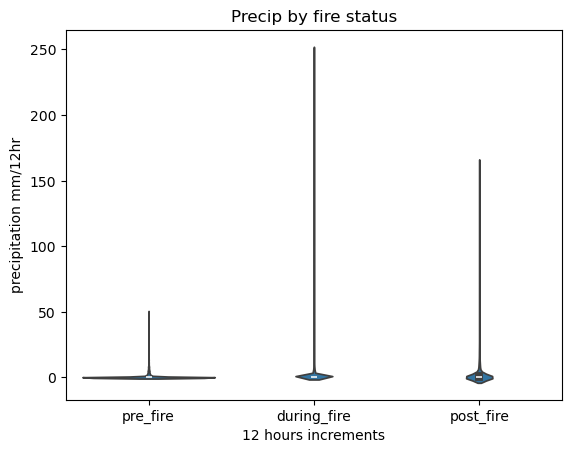

In [72]:
sns.violinplot(data=fires[["fr_active_status", "precipitation"]].dropna(), x = "fr_active_status" , y="precipitation")

plt.title("Precip by fire status")
plt.xlabel("12 hours increments")
plt.ylabel("precipitation mm/12hr")
plt.show()

Hard to see from the above plots, but I think that postfire has a higher central tendency than the others. Maybe look at the distributions CI's and use a KSTEST? 



In [81]:
print("70th Quantile for different fire statuses")

print(fires.groupby("fr_active_status").precipitation.quantile(0.7))


print("80th Quantile for different fire statuses")

print(fires.groupby("fr_active_status").precipitation.quantile(0.8))

print("90th Quantile for different fire statuses")

print(fires.groupby("fr_active_status").precipitation.quantile(0.9))



### TO DO KSTEST

70th Quantile for different fire statuses
fr_active_status
during_fire    0.000
post_fire      0.383
pre_fire       0.000
Name: precipitation, dtype: float64
80th Quantile for different fire statuses
fr_active_status
during_fire    0.37
post_fire      1.97
pre_fire       0.03
Name: precipitation, dtype: float64
90th Quantile for different fire statuses
fr_active_status
during_fire    2.480
post_fire      8.471
pre_fire       1.071
Name: precipitation, dtype: float64


# How many fires ended after an *uptick* in precipitation? 

Instead of looking at the raw amount of precipitation after a fire stopped, looking at fires that stopped after an uptick in precip specifically. This is a little scary given the 12-hourly stuff, so may need to consider a rolling difference, or 24 hour difference etc. 

In [93]:
fires.t = fires.t.astype("datetime64[ns]")
fires = fires.sort_values(by = ["UfireID", "t"])
fires["precip_diff"] = fires.groupby("UfireID").precipitation.diff() ## Positive is when the amount of rain goes up, negative down

In [ ]:
fires.loc[post_fire_mask,:].precip_diff.hist() ## For the 12 hours after the last spread, seems like a a mean 1.58 mm per 12 hours

print(f" There was a mean of {fires.loc[post_fire_mask,:].precip_diff.mean()} difference in precip in the 12 hours after last fire growth")

print(f" 50th quantile {fires.loc[post_fire_mask,:].precip_diff.quantile(.5)}")
print(f" 60th quantile {fires.loc[post_fire_mask,:].precip_diff.quantile(.6)}")
print(f" 70th quantile {fires.loc[post_fire_mask,:].precip_diff.quantile(.7)}")
print(f" 80th quantile {fires.loc[post_fire_mask,:].precip_diff.quantile(.8)}")
print(f" 90th quantile {fires.loc[post_fire_mask,:].precip_diff.quantile(.9)}")

print(f"{len(fires.loc[post_fire_mask & (fires.precip_diff > 0),:].precip_diff) / len(fires.loc[post_fire_mask ,:].precip_diff)} Percent of fires ended after a positve increase in precip in the 12 hours after the last fire growth detection.")

In [ ]:
# Of the positives, what was the range in precipitation values? 

fires.loc[post_fire_mask & (fires.precip_diff > 0),:].precip_diff.hist() # I would love to match this too final fire size. I bet there is is trad off!

print(fires.loc[post_fire_mask & (fires.precip_diff > 0),:].precip_diff.min())

In [ ]:
## Percent of fires where weather stayed the same


print(f"{len(fires.loc[post_fire_mask & (fires.precip_diff == 0),:].precip_diff) / len(fires.loc[post_fire_mask ,:].precip_diff)} Percent of fires ended after no change in precip in the 12 hours after the last fire growth detection.")

In [ ]:
print(f"{len(fires.loc[post_fire_mask & (fires.precip_diff < 0),:].precip_diff) / len(fires.loc[post_fire_mask ,:].precip_diff)} Percent of fires ended after a decrease in precip in the 12 hours after the last fire growth detection.")


print(f" NOTE Percentages coming from {len(fires.loc[post_fire_mask ,:].UfireID.unique())} fires.")

In [114]:
multi_day_mask =

0.17613365155131264 Percent of fires ended after a decrease in precip in the 12 hours after the last fire growth detection.
 NOTE Percentages coming from 4190 fires.


# Look at active fire (smoldering) time vs actualy expansion time